# 🔐 Multimodal Biometrics — Face Recognition

---
## 0. Setup

In [ ]:
!git clone https://github.com/deepanrajm/GL_MML.git

In [ ]:
!pip install insightface onnxruntime-gpu opencv-python-headless matplotlib -q
# If GPU version fails, use: pip install onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 13.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 35.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Ready!")

✅ Ready!


In [ ]:
# Load InsightFace model
from insightface.app import FaceAnalysis

print("Loading InsightFace...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))
print("✅ InsightFace loaded!")
print("   This model detects faces AND extracts 512-dim embeddings.")
print("   Same concept as CLIP: image → encoder → embedding → compare.")

Loading InsightFace...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 93163.12KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

✅ dhini_c
✅ dhoni_a
✅ dhoni_b
✅ kholi_a
✅ kholi_b
✅ kholi_c
✅ sachin_a
✅ sachin_b
✅ sachin_c

9 images loaded!


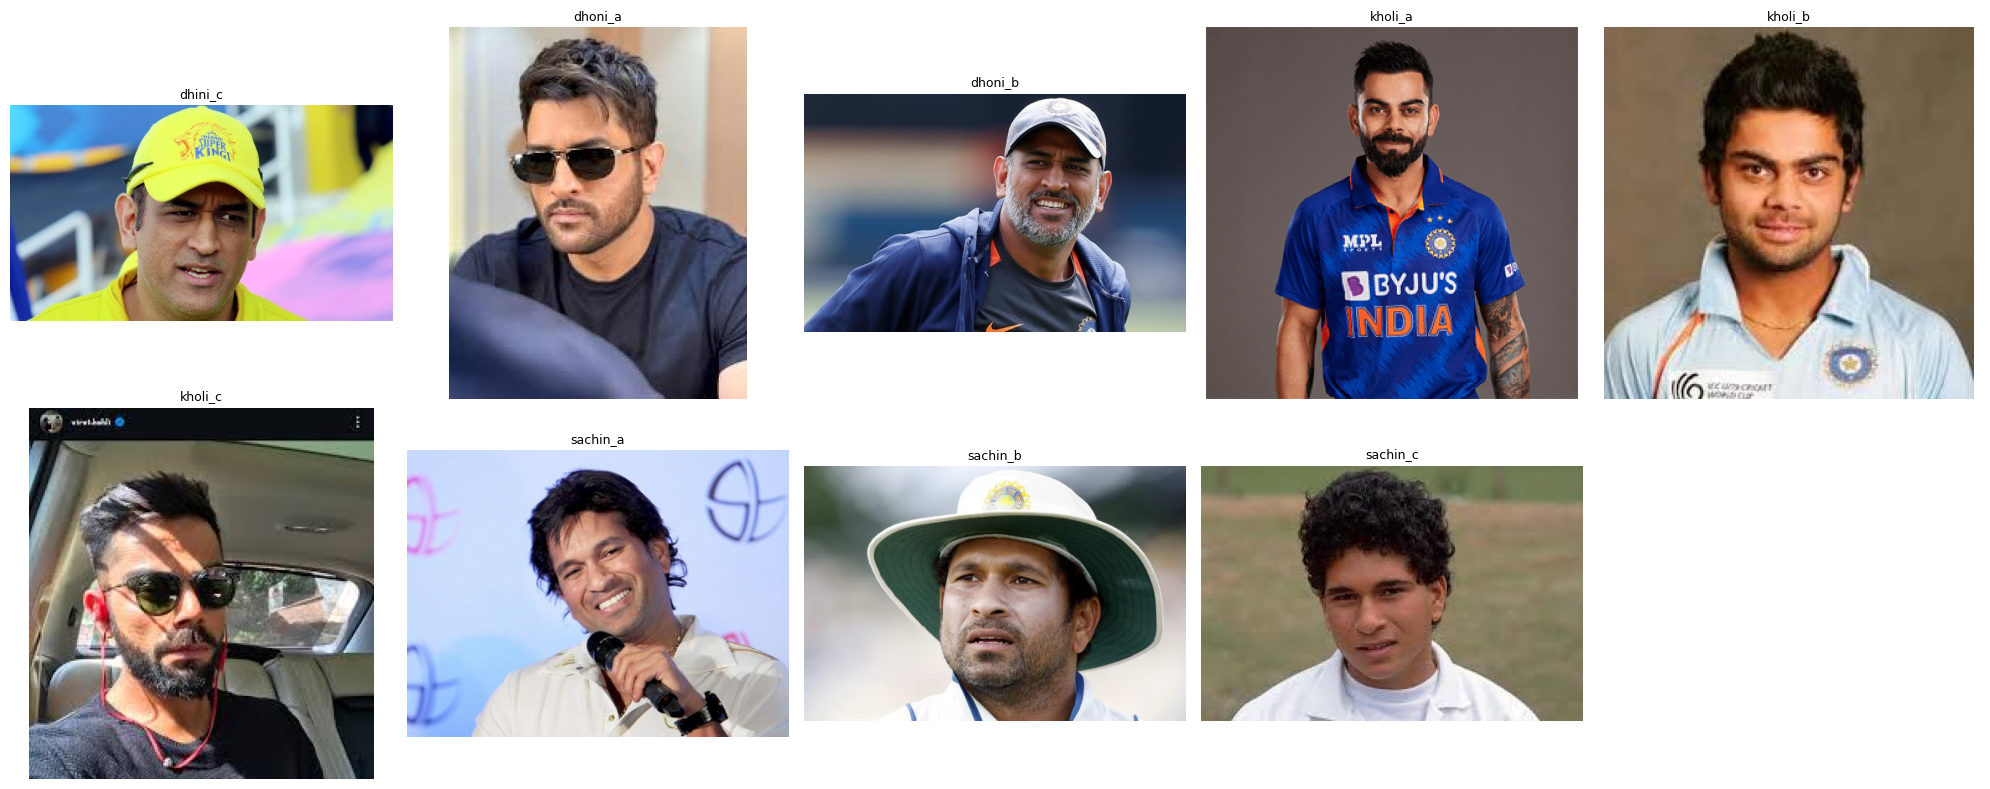

In [ ]:


# 🔄 CHANGE this path to your folder with face photos
# Suggested: 3-4 people, 2-3 photos each
# Name files like: person1_a.jpg, person1_b.jpg, person2_a.jpg, etc.
face_folder = "GL_MML/Unit_4/faces"

face_images = {}
for f in sorted(os.listdir(face_folder)):
    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
        name = os.path.splitext(f)[0]
        face_images[name] = cv2.imread(os.path.join(face_folder, f))
        print(f"✅ {name}")

print(f"\n{len(face_images)} images loaded!")

# Show all
n = len(face_images)
cols = min(n, 5)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if rows == 1 and cols == 1:
    axes = [axes]
elif rows == 1:
    axes = list(axes)
else:
    axes = [ax for row in axes for ax in row]

for idx, (name, img) in enumerate(face_images.items()):
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(name, fontsize=9)
    axes[idx].axis('off')
for idx in range(len(face_images), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

---
---
# Task 1: Face Recognition

Same concept as CLIP, but specialized for faces:

```
CLIP:        Any image → [ViT Encoder] → 512-dim embedding → cosine similarity
InsightFace: Face image → [ArcFace Encoder] → 512-dim embedding → cosine similarity

Same person  → high similarity (> 0.4)
Different person → low similarity (< 0.3)
```

---

In [ ]:
# ============================================
# 1.1 Detect faces and extract embeddings
# ============================================

face_data = {}  # {name: {embedding, bbox, image}}

print("═" * 70)
print("Detecting faces and extracting embeddings")
print("═" * 70)

for name, img in face_images.items():
    faces = app.get(img)
    if len(faces) == 0:
        print(f"  ❌ {name}: No face detected!")
        continue

    face = faces[0]  # take the first (largest) face
    face_data[name] = {
        'embedding': face.embedding,  # 512-dim vector
        'bbox': face.bbox.astype(int),
        'age': face.age,
        'gender': 'Male' if face.gender == 1 else 'Female',
    }
    print(f"  ✅ {name}: face detected (age~{face.age}, {face_data[name]['gender']})")
    print(f"     Embedding: {face.embedding.shape} → 512-dim vector (like CLIP!)")

print(f"\n{len(face_data)} faces extracted!")

══════════════════════════════════════════════════════════════════════
Detecting faces and extracting embeddings
══════════════════════════════════════════════════════════════════════
  ✅ dhini_c: face detected (age~47, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ dhoni_a: face detected (age~36, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ dhoni_b: face detected (age~47, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ kholi_a: face detected (age~40, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ kholi_b: face detected (age~31, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ kholi_c: face detected (age~33, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ sachin_a: face detected (age~46, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ sachin_b: face detected (age~41, Male)
     Embedding: (512,) → 512-dim vector (like CLIP!)
  ✅ sachin_c: face detected (age~33, Male)
     Embedd

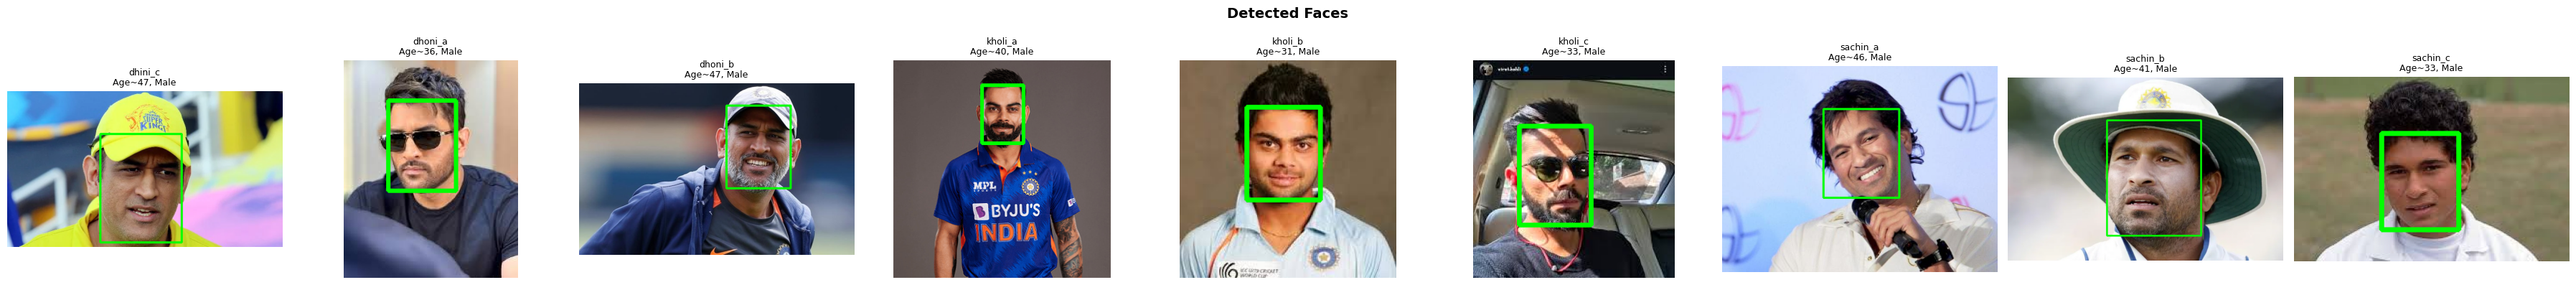

In [ ]:
# ============================================
# 1.2 Show detected faces with bounding boxes
# ============================================

n = len(face_data)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for idx, (name, data) in enumerate(face_data.items()):
    img_rgb = cv2.cvtColor(face_images[name], cv2.COLOR_BGR2RGB).copy()
    bbox = data['bbox']
    cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)

    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{name}\nAge~{data['age']}, {data['gender']}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle("Detected Faces", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

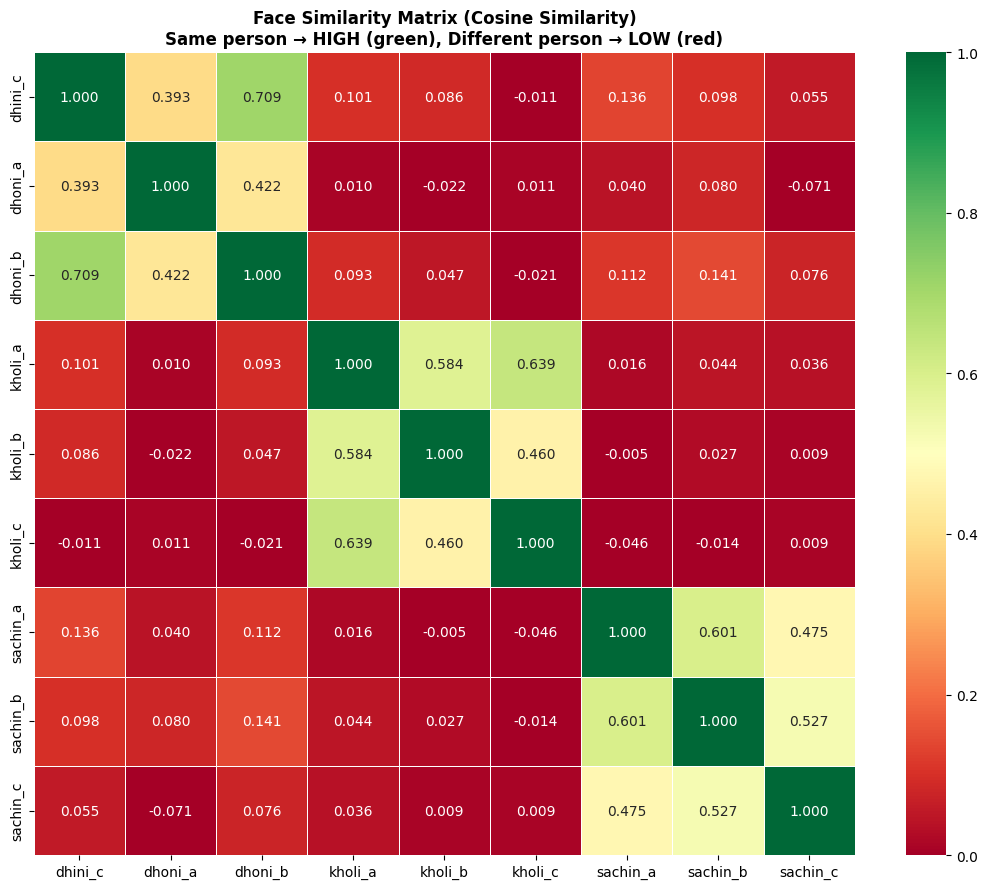

💡 Same concept as CLIP similarity!
   CLIP: image_embedding · text_embedding = how well they match
   ArcFace: face_embedding_1 · face_embedding_2 = same person?

   Threshold: > 0.4 → likely same person
              < 0.3 → likely different person


In [ ]:
# ============================================
# 1.3 Similarity matrix — Who matches whom?
# ============================================

names = list(face_data.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        emb_i = face_data[names[i]]['embedding']
        emb_j = face_data[names[j]]['embedding']
        # Cosine similarity — same as CLIP!
        sim = np.dot(emb_i, emb_j) / (np.linalg.norm(emb_i) * np.linalg.norm(emb_j))
        sim_matrix[i][j] = sim

import seaborn as sns

plt.figure(figsize=(max(8, n*1.2), max(6, n*1.0)))
sns.heatmap(sim_matrix,
            xticklabels=names, yticklabels=names,
            annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white')
plt.title("Face Similarity Matrix (Cosine Similarity)\nSame person → HIGH (green), Different person → LOW (red)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Same concept as CLIP similarity!")
print("   CLIP: image_embedding · text_embedding = how well they match")
print("   ArcFace: face_embedding_1 · face_embedding_2 = same person?")
print("\n   Threshold: > 0.4 → likely same person")
print("              < 0.3 → likely different person")

In [ ]:
# ============================================
# 1.4 Identify a query face
# ============================================

# Use the first image as the "database" and second as "query"
# In real biometrics: database = enrolled faces, query = person at the door

if len(names) >= 2:
    query_name = names[-1]  # last image as query
    database_names = names[:-1]  # rest as database

    query_emb = face_data[query_name]['embedding']

    print("═" * 70)
    print(f"Query: {query_name} — Who is this person?")
    print("═" * 70)

    scores = []
    for db_name in database_names:
        db_emb = face_data[db_name]['embedding']
        sim = np.dot(query_emb, db_emb) / (np.linalg.norm(query_emb) * np.linalg.norm(db_emb))
        scores.append((db_name, sim))

    scores.sort(key=lambda x: x[1], reverse=True)

    for db_name, sim in scores:
        match = "✅ MATCH" if sim > 0.4 else "❌ No match"
        print(f"  {db_name:20s} similarity: {sim:.4f}  {match}")

    best_name, best_score = scores[0]
    print(f"\n  → Best match: {best_name} (score: {best_score:.4f})")
else:
    print("Need at least 2 images for identification demo.")

══════════════════════════════════════════════════════════════════════
Query: sachin_c — Who is this person?
══════════════════════════════════════════════════════════════════════
  sachin_b             similarity: 0.5267  ✅ MATCH
  sachin_a             similarity: 0.4748  ✅ MATCH
  dhoni_b              similarity: 0.0756  ❌ No match
  dhini_c              similarity: 0.0552  ❌ No match
  kholi_a              similarity: 0.0360  ❌ No match
  kholi_b              similarity: 0.0088  ❌ No match
  kholi_c              similarity: 0.0088  ❌ No match
  dhoni_a              similarity: -0.0709  ❌ No match

  → Best match: sachin_b (score: 0.5267)


In [ ]:
!pip install yt-dlp pydub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.4/182.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.5 MB/s eta 0:00:00


In [ ]:


# Download audio from YouTube
import subprocess
# Replace URL with actual YouTube link
subprocess.run(["yt-dlp", "-x", "--audio-format", "wav",
                "-o", "sachin_c.wav", "https://www.youtube.com/shorts/SWExxBMoTb4"])

CompletedProcess(args=['yt-dlp', '-x', '--audio-format', 'wav', '-o', 'sachin_c.wav', 'https://www.youtube.com/shorts/SWExxBMoTb4'], returncode=0)